# Notebook 02 — Baseline TF-IDF + Régression Logistique

**Projet** : Classification automatique de produits pour une marketplace française  
**Notebook précédent** : `01_eda.ipynb` (exploration et nettoyage)

---

## Objectifs

1. Entraîner un modèle baseline simple et reproductible
2. Mesurer ses performances avec les bonnes métriques (F1-macro)
3. Analyser ses erreurs pour comprendre ses limites
4. Sauvegarder un point de référence à dépasser au notebook 03 (embeddings)

## Approche

- **Vectorisation** : TF-IDF (unigrammes + bigrammes)
- **Modèle** : Régression Logistique multinomiale, `class_weight='balanced'`
- **Splits** : Train (70%) / Validation (15%) / Test (15%), stratifiés sur `prdtypecode`
- **Métrique principale** : F1-macro

Le test set n'est utilisé **qu'une seule fois** au bloc 9 pour la mesure finale.

In [1]:
"""
Notebook 02 : Baseline TF-IDF + Régression Logistique
Charge le DataFrame nettoyé du notebook 01 et entraîne un modèle de référence.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from time import time

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

# Config affichage
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 100)
sns.set_theme(style="whitegrid", context="notebook")

# Reproductibilité
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Setup OK")

Setup OK


In [2]:
# Chargement du DataFrame nettoyé sauvegardé au notebook 01
INPUT_PATH = Path("../data/processed/df_clean.parquet")
assert INPUT_PATH.exists(), f"❌ Fichier introuvable : {INPUT_PATH.resolve()}"

t0 = time()
df = pd.read_parquet(INPUT_PATH)
print(f"✅ Chargement en {time() - t0:.2f}s")

print(f"\nShape : {df.shape}")
print(f"Colonnes : {list(df.columns)}")
print(f"\nAperçu :")
display(df.head(3))

# Vérifications de cohérence
print(f"\nNb classes : {df['prdtypecode'].nunique()}")
print(f"Valeurs manquantes par colonne :")
display(df.isna().sum().to_frame("n_missing").T)

✅ Chargement en 0.40s

Shape : (84916, 6)
Colonnes : ['designation', 'description', 'text', 'text_clean', 'has_description', 'prdtypecode']

Aperçu :


,designation,description,text,text_clean,has_description,prdtypecode
0,Olivia: Personalisiertes Notizbuch / 150 Seiten / Punktraster / Ca Din A5 / Rosen-Design,None,Olivia: Personalisiertes Notizbuch / 150 Seiten / Punktraster / Ca Din A5 / Rosen-Design,olivia personalisiertes notizbuch 150 seiten punktraster ca din a5 rosen design,False,10
1,Journal Des Arts (Le) N° 133 Du 28/09/2001 - L'art Et Son Marche Salon D'art Asiatique A Paris -...,None,Journal Des Arts (Le) N° 133 Du 28/09/2001 - L'art Et Son Marche Salon D'art Asiatique A Paris -...,journal des arts le n 133 du 28 09 2001 l art et son marche salon d art asiatique a paris jacque...,False,2280
2,Grand Stylet Ergonomique Bleu Gamepad Nintendo Wii U - Speedlink Pilot Style,PILOT STYLE Touch Pen de marque Speedlink est 1 stylet ergonomique pour GamePad Nintendo Wii U.<...,Grand Stylet Ergonomique Bleu Gamepad Nintendo Wii U - Speedlink Pilot Style PILOT STYLE Touch P...,grand stylet ergonomique bleu gamepad nintendo wii u speedlink pilot style pilot style touch pen...,True,50



Nb classes : 27
Valeurs manquantes par colonne :


,designation,description,text,text_clean,has_description,prdtypecode
n_missing,0,29800,0,0,0,0


## 1. Split train / validation / test

On crée 3 splits **stratifiés** sur `prdtypecode` :
- **Train (70%)** : entraînement du modèle
- **Validation (15%)** : analyse d'erreurs, comparaison de variantes
- **Test (15%)** : mesure finale, utilisé une seule fois au bloc 9

La stratification garantit que la distribution des 27 classes est préservée dans chaque split.

In [3]:
# Features (X) et cible (y)
X = df["text_clean"]
y = df["prdtypecode"]

# Étape 1 : séparer (train + val) vs test (15%)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y,
    test_size=0.15,
    stratify=y,
    random_state=RANDOM_STATE,
)

# Étape 2 : séparer train vs val (15% du total = ~17.6% de trainval)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.15 / 0.85,   # 15% du total
    stratify=y_trainval,
    random_state=RANDOM_STATE,
)

# Vérification des tailles
print(f"Train : {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Val   : {len(X_val):,} ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test  : {len(X_test):,} ({len(X_test)/len(X)*100:.1f}%)")
print(f"Total : {len(X_train) + len(X_val) + len(X_test):,}")

Train : 59,440 (70.0%)
Val   : 12,738 (15.0%)
Test  : 12,738 (15.0%)
Total : 84,916


In [4]:
# Vérification : la distribution des classes est-elle préservée dans chaque split ?
dist_check = pd.DataFrame({
    "train": y_train.value_counts(normalize=True).sort_index() * 100,
    "val":   y_val.value_counts(normalize=True).sort_index() * 100,
    "test":  y_test.value_counts(normalize=True).sort_index() * 100,
}).round(2)

dist_check["max_ecart"] = (
    dist_check[["train", "val", "test"]].max(axis=1)
    - dist_check[["train", "val", "test"]].min(axis=1)
).round(3)

print("Distribution (%) par split, par classe :")
display(dist_check)

print(f"\nÉcart maximal entre splits sur une classe : {dist_check['max_ecart'].max():.3f}%")
print("→ Si < 0.5%, la stratification est très bien préservée.")

Distribution (%) par split, par classe :


,train,val,test,max_ecart
prdtypecode,,,,
10,3.67,3.67,3.67,0.00
40,2.95,2.95,2.95,0.00
50,1.98,1.98,1.98,0.00
60,0.98,0.98,0.98,0.00
1140,3.14,3.15,3.15,0.01
1160,4.66,4.66,4.66,0.00
1180,0.90,0.90,0.90,0.00
1280,5.74,5.73,5.74,0.01
1281,2.44,2.43,2.44,0.01



Écart maximal entre splits sur une classe : 0.010%
→ Si < 0.5%, la stratification est très bien préservée.


## 2. Vectorisation TF-IDF

On transforme chaque texte produit en un vecteur de fréquences pondérées (TF-IDF).

### Choix d'hyperparamètres

| Paramètre | Valeur | Justification |
|-----------|--------|---------------|
| `ngram_range` | `(1, 2)` | Capture les unigrammes (mots seuls) et les bigrammes (paires de mots) → ex. `"machine learning"` devient un token distinct |
| `min_df` | `5` | Ignore les tokens qui apparaissent dans moins de 5 produits → supprime le bruit (typos, mots ultra-rares) |
| `max_df` | `0.95` | Ignore les tokens qui apparaissent dans plus de 95% des produits → supprime les mots trop génériques |
| `max_features` | `50_000` | Plafond pour limiter la dimensionnalité et le temps d'entraînement |
| `sublinear_tf` | `True` | Applique `log(1 + tf)` au lieu de `tf` brut → atténue l'effet des mots très répétés (ex. "piscine" 22k fois dans une classe) |

Le vectorizer est **fitté uniquement sur le train** pour éviter toute fuite de données depuis val/test.

In [5]:
# Configuration du vectorizer
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.95,
    max_features=50_000,
    sublinear_tf=True,
)

# Fit sur le train UNIQUEMENT, transform sur les 3 splits
print("Fit du vectorizer sur le train...")
t0 = time()
X_train_vec = vectorizer.fit_transform(X_train)
print(f"  → {time() - t0:.1f}s")

print("Transform val et test...")
t0 = time()
X_val_vec = vectorizer.transform(X_val)
X_test_vec = vectorizer.transform(X_test)
print(f"  → {time() - t0:.1f}s")

# Diagnostics
print(f"\nVocabulaire appris : {len(vectorizer.vocabulary_):,} tokens")
print(f"Shape X_train_vec : {X_train_vec.shape}")
print(f"Shape X_val_vec   : {X_val_vec.shape}")
print(f"Shape X_test_vec  : {X_test_vec.shape}")

# Densité de la matrice sparse
density = X_train_vec.nnz / (X_train_vec.shape[0] * X_train_vec.shape[1]) * 100
print(f"\nDensité matrice train : {density:.3f}% (matrice sparse, c'est normal)")
print(f"Mémoire X_train_vec   : {X_train_vec.data.nbytes / 1024**2:.1f} Mo")

Fit du vectorizer sur le train...
  → 15.6s
Transform val et test...
  → 6.1s

Vocabulaire appris : 50,000 tokens
Shape X_train_vec : (59440, 50000)
Shape X_val_vec   : (12738, 50000)
Shape X_test_vec  : (12738, 50000)

Densité matrice train : 0.171% (matrice sparse, c'est normal)
Mémoire X_train_vec   : 38.7 Mo


In [6]:
# Top 20 tokens les plus discriminants au global (IDF élevé = rare)
# (idf_ est inversement proportionnel à la fréquence du token)
idf_scores = pd.Series(
    vectorizer.idf_,
    index=vectorizer.get_feature_names_out()
)

# Quelques exemples : mots fréquents (IDF bas) vs rares (IDF haut)
print("Top 10 tokens LES PLUS FRÉQUENTS (IDF le plus bas, peu discriminants) :")
print(idf_scores.nsmallest(10).round(3).to_string())

print("\nTop 10 tokens LES PLUS RARES (IDF le plus haut, parmi les conservés) :")
print(idf_scores.nlargest(10).round(3).to_string())

# Quelques bigrammes
bigrams = [tok for tok in vectorizer.get_feature_names_out() if " " in tok]
print(f"\nNombre de bigrammes dans le vocabulaire : {len(bigrams):,}")
print(f"Exemples de bigrammes : {bigrams[:15]}")

Top 10 tokens LES PLUS FRÉQUENTS (IDF le plus bas, peu discriminants) :
de      1.415
et      1.706
la      1.757
pour    1.858
en      1.897
le      1.953
les     2.073
un      2.217
des     2.239
du      2.248

Top 10 tokens LES PLUS RARES (IDF le plus haut, parmi les conservés) :
15l                10.201
17 32inch          10.201
17t                10.201
1pc un             10.201
1x autocollants    10.201
220 pacifique      10.201
2207 motor         10.201
25 28              10.201
25kg 6kg           10.201
32inch             10.201

Nombre de bigrammes dans le vocabulaire : 34,244
Exemples de bigrammes : ['000 heures', '000 litres', '000 sable', '0001pt mso', '01 01', '01 02', '01 03', '01 04', '01 05', '01 06', '01 07', '01 08', '01 09', '01 10', '01 11']


## 3. Entraînement de la baseline : Régression Logistique

### Choix d'hyperparamètres

| Paramètre | Valeur | Justification |
|-----------|--------|---------------|
| `solver` | `saga` | Solveur scalable, compatible avec L1/L2 et multinomial, supporte les matrices sparses |
| `multi_class` | `multinomial` | Vraie régression logistique multinomiale (softmax), pas un agrégat de one-vs-rest |
| `class_weight` | `balanced` | Compense le déséquilibre des classes en ajustant les poids inversement à leur fréquence |
| `C` | `1.0` | Inverse de la régularisation, valeur par défaut conservée pour la baseline |
| `max_iter` | `1000` | Plafond généreux pour garantir la convergence |
| `n_jobs` | `-1` | Parallélisation sur tous les cores CPU disponibles |

In [9]:
model = LogisticRegression(
    solver="liblinear",
    class_weight="balanced",
    C=1.0,
    max_iter=300,
    random_state=RANDOM_STATE,
)

print("Entraînement baseline LogReg (config rapide)...")
print()

t0 = time()
model.fit(X_train_vec, y_train)
train_time = time() - t0

print(f"✅ Entraînement terminé en {train_time:.1f}s ({train_time/60:.1f} min)")
print(f"   Itérations max effectuées (parmi 27 classifieurs OvR) : {model.n_iter_.max()}")
if model.n_iter_.max() >= 300:
    print("⚠️  Certains classifieurs ont atteint max_iter, convergence partielle.")
else:
    print("→ Tous les classifieurs ont convergé.")

Entraînement baseline LogReg (config rapide)...

✅ Entraînement terminé en 40.2s (0.7 min)
   Itérations max effectuées (parmi 27 classifieurs OvR) : 12
→ Tous les classifieurs ont convergé.


## 4. Évaluation : métriques globales

On évalue le modèle sur **train** et **validation**, jamais sur test (ça vient au bloc 9).

Trois métriques affichées :
- **Accuracy** : taux global de bonnes prédictions
- **F1-macro** : moyenne non pondérée des F1 par classe (notre **métrique principale** au vu du déséquilibre)
- **F1-weighted** : moyenne pondérée par effectif de classe (plus indulgent que F1-macro)

L'écart train ↔ val nous renseigne sur le **sur-apprentissage** éventuel.

In [10]:
# Prédictions sur train et validation
print("Prédictions sur train...")
t0 = time()
y_train_pred = model.predict(X_train_vec)
print(f"  → {time() - t0:.1f}s")

print("Prédictions sur validation...")
t0 = time()
y_val_pred = model.predict(X_val_vec)
print(f"  → {time() - t0:.1f}s")

# Calcul des métriques
metrics = pd.DataFrame({
    "Accuracy": [
        accuracy_score(y_train, y_train_pred),
        accuracy_score(y_val, y_val_pred),
    ],
    "F1-macro": [
        f1_score(y_train, y_train_pred, average="macro"),
        f1_score(y_val, y_val_pred, average="macro"),
    ],
    "F1-weighted": [
        f1_score(y_train, y_train_pred, average="weighted"),
        f1_score(y_val, y_val_pred, average="weighted"),
    ],
}, index=["Train", "Validation"]).round(4)

print("\n" + "=" * 60)
print("MÉTRIQUES GLOBALES")
print("=" * 60)
display(metrics)

# Gap train ↔ val (indicateur de sur-apprentissage)
gap_acc = metrics.loc["Train", "Accuracy"] - metrics.loc["Validation", "Accuracy"]
gap_f1 = metrics.loc["Train", "F1-macro"] - metrics.loc["Validation", "F1-macro"]

print(f"\nGap Train → Val :")
print(f"  Accuracy : {gap_acc*100:+.2f} points")
print(f"  F1-macro : {gap_f1*100:+.2f} points")

Prédictions sur train...
  → 0.1s
Prédictions sur validation...
  → 0.0s

MÉTRIQUES GLOBALES


,Accuracy,F1-macro,F1-weighted
Train,0.8713,0.8706,0.8706
Validation,0.8067,0.7975,0.8070



Gap Train → Val :
  Accuracy : +6.46 points
  F1-macro : +7.31 points


### Observations

- **F1-macro Validation : 0.7975** — baseline solide en ~30s d'entraînement.
- **Gap train/val ≈ 7 points** : sur-apprentissage modéré, attribuable au vocabulaire large (50k features) et à la régularisation par défaut (C=1.0). Pistes V2 : baisser C ou réduire max_features.
- **Accuracy ≈ F1-macro** (écart < 1pt) : le `class_weight='balanced'` empêche le modèle de privilégier les classes majoritaires.
- **Vitesse d'inférence < 15ms** sur 12k produits : modèle scalable.

## 5. Performances détaillées par classe

Les métriques globales cachent des disparités. Cette section regarde la performance **classe par classe** pour identifier :
- Les classes "faciles" (vocabulaire ultra-discriminant)
- Les classes "difficiles" qui plombent le F1-macro
- Les patterns de difficulté liés à ce qu'on a vu en EDA (texte pauvre, confusions sémantiques)

In [11]:
# Rapport détaillé : precision, recall, F1 par classe + moyennes
print("=" * 75)
print("CLASSIFICATION REPORT (Validation)")
print("=" * 75)
print(classification_report(y_val, y_val_pred, digits=3, zero_division=0))

CLASSIFICATION REPORT (Validation)
              precision    recall  f1-score   support

          10      0.464     0.690     0.555       468
          40      0.744     0.649     0.693       376
          50      0.764     0.885     0.820       252
          60      0.919     0.816     0.864       125
        1140      0.742     0.796     0.768       401
        1160      0.923     0.912     0.918       593
        1180      0.640     0.696     0.667       115
        1280      0.734     0.536     0.619       730
        1281      0.642     0.597     0.619       310
        1300      0.847     0.923     0.884       757
        1301      0.942     0.934     0.938       121
        1302      0.761     0.765     0.763       374
        1320      0.799     0.776     0.787       486
        1560      0.843     0.800     0.821       761
        1920      0.886     0.926     0.905       645
        1940      0.819     0.934     0.873       121
        2060      0.767     0.770     0.769   

In [12]:
# Transformation en DataFrame pour analyser proprement
report_dict = classification_report(y_val, y_val_pred, output_dict=True, zero_division=0)

# On garde uniquement les lignes par classe (les codes), pas les moyennes
class_rows = {k: v for k, v in report_dict.items() if k.isdigit()}
report_df = pd.DataFrame(class_rows).T
report_df = report_df.rename(columns={"support": "n_val"})
report_df.index = report_df.index.astype(int)
report_df = report_df.round(3)

# Croisement avec les insights de l'EDA (notebook 01)
# On recharge les stats par classe du notebook 01
text_stats_per_class = (
    df.groupby("prdtypecode")
    .agg(
        median_words_total=("text", lambda s: s.str.split().str.len().median()),
        pct_desc_missing=("has_description", lambda x: (1 - x.mean()) * 100),
    )
    .round(1)
)

# Fusion
report_full = report_df.join(text_stats_per_class)
report_full = report_full.sort_values("f1-score", ascending=True)

print("Performance par classe (triées du pire F1 au meilleur) :")
display(report_full)

Performance par classe (triées du pire F1 au meilleur) :


,precision,recall,f1-score,n_val,median_words_total,pct_desc_missing
10,0.464,0.690,0.555,468.0,8.0,89.2
1280,0.734,0.536,0.619,730.0,83.0,21.9
1281,0.642,0.597,0.619,310.0,57.0,23.8
1180,0.640,0.696,0.667,115.0,9.0,80.0
40,0.744,0.649,0.693,376.0,8.0,65.5
2705,0.711,0.756,0.733,414.0,84.0,37.1
2582,0.764,0.719,0.741,388.0,114.0,2.4
2403,0.816,0.694,0.750,716.0,10.0,97.4
2462,0.804,0.714,0.756,213.0,9.0,96.3
1302,0.761,0.765,0.763,374.0,114.0,11.1


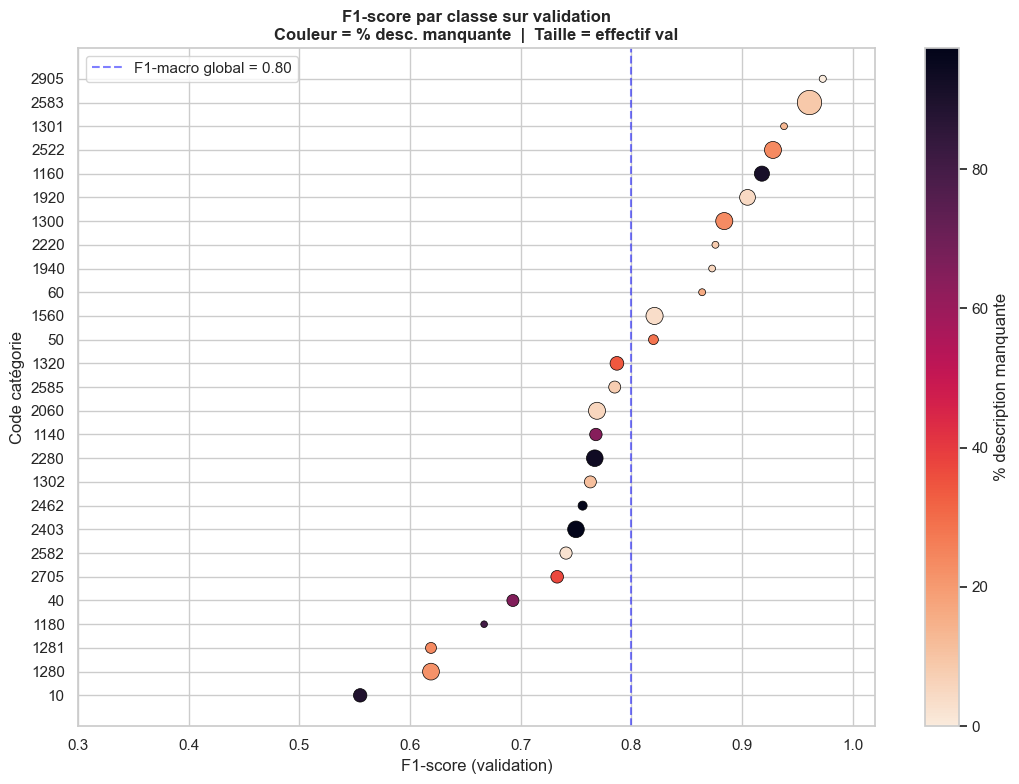

In [13]:
# Plot F1 par classe, coloré par % desc manquante
fig, ax = plt.subplots(figsize=(11, 8))
plot_data = report_full.reset_index().rename(columns={"index": "prdtypecode"})
plot_data["prdtypecode"] = plot_data["prdtypecode"].astype(str)

scatter = ax.scatter(
    plot_data["f1-score"],
    plot_data["prdtypecode"],
    c=plot_data["pct_desc_missing"],
    cmap="rocket_r",
    s=plot_data["n_val"] / 5,
    edgecolors="black",
    linewidths=0.5,
)
ax.axvline(0.80, color="blue", linestyle="--", alpha=0.5, label="F1-macro global = 0.80")
ax.set_xlim(0.3, 1.02)
ax.set_xlabel("F1-score (validation)")
ax.set_ylabel("Code catégorie")
ax.set_title(
    "F1-score par classe sur validation\n"
    "Couleur = % desc. manquante  |  Taille = effectif val",
    fontsize=12,
    fontweight="bold",
)
ax.legend()
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("% description manquante")
plt.tight_layout()
plt.show()

### Observations

- Les classes les plus difficiles concentrent les caractéristiques EDA défavorables : description manquante + texte court (cf. classes 10, 40, 1180).
- Les classes "faciles" (F1 > 0.92) bénéficient soit d'un vocabulaire ultra-spécifique (2583, 2522), soit d'un texte riche (2905, 1301).
- Les confusions anticipées au notebook 01 (livres lots/occasion, jouets/puériculture) se manifestent dans les precision/recall asymétriques.

## 6. Matrice de confusion

La matrice de confusion visualise les patterns d'erreur entre classes : ligne = classe réelle, colonne = classe prédite.

On affiche ici la version **normalisée par ligne** (recall) : chaque case `(i, j)` indique le **pourcentage** de produits de la classe `i` prédits comme `j`.

- Diagonale = bonnes prédictions
- Hors diagonale = confusions à analyser

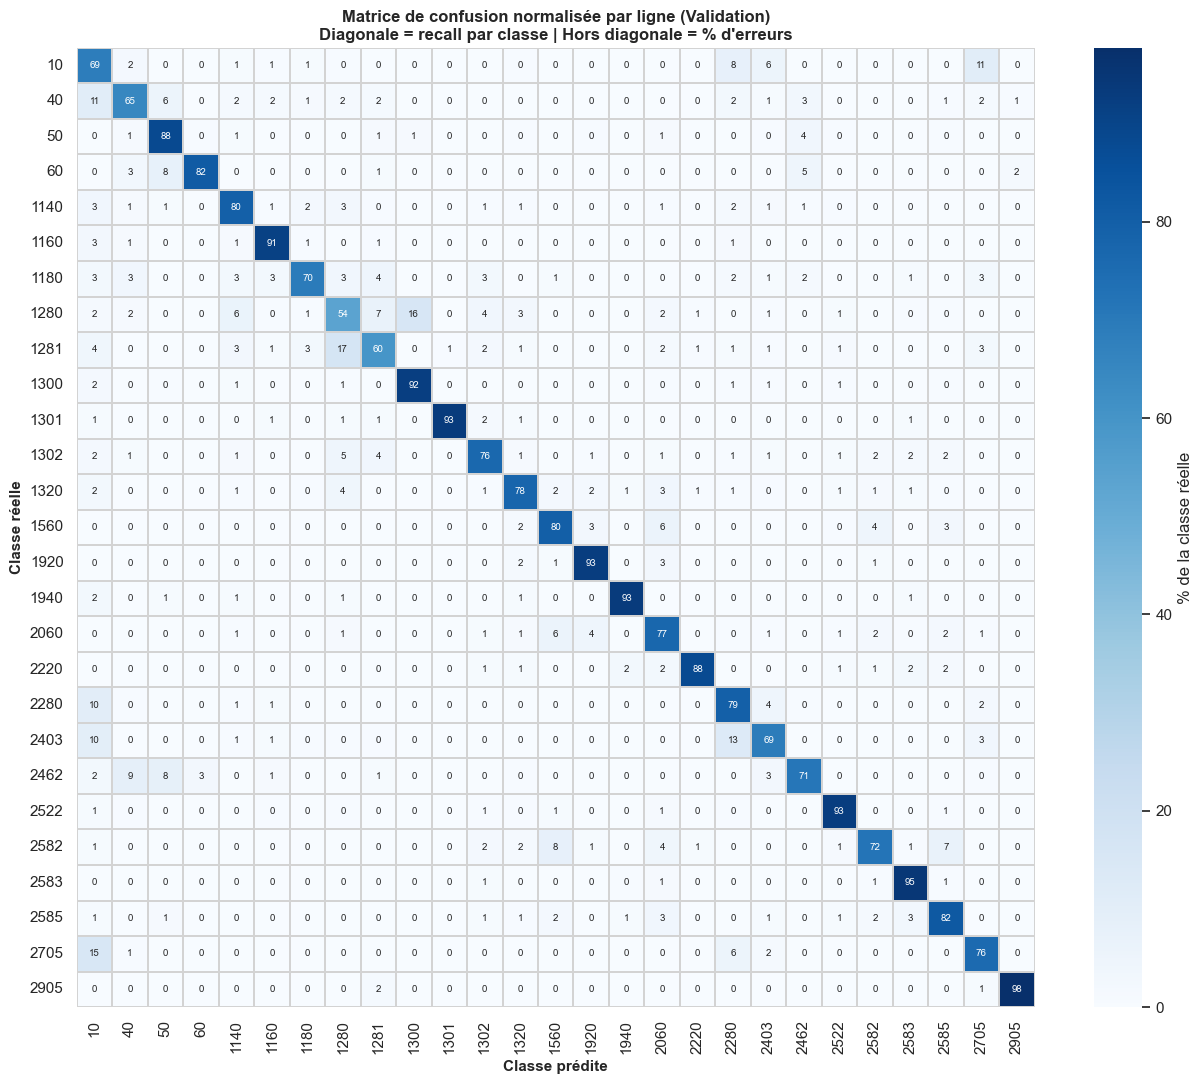

In [14]:
# Classes triées (par code numérique pour lisibilité)
classes_sorted = sorted(df["prdtypecode"].unique())

# Matrice de confusion brute
cm = confusion_matrix(y_val, y_val_pred, labels=classes_sorted)

# Normalisation par ligne (= recall par classe)
cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

# Plot heatmap
fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    xticklabels=classes_sorted,
    yticklabels=classes_sorted,
    cbar_kws={"label": "% de la classe réelle"},
    linewidths=0.3,
    linecolor="lightgray",
    ax=ax,
    annot_kws={"size": 7},
)
ax.set_xlabel("Classe prédite", fontsize=11, fontweight="bold")
ax.set_ylabel("Classe réelle", fontsize=11, fontweight="bold")
ax.set_title(
    "Matrice de confusion normalisée par ligne (Validation)\n"
    "Diagonale = recall par classe | Hors diagonale = % d'erreurs",
    fontsize=12,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

In [15]:
# Identifier automatiquement les paires de classes les plus confondues
# (on regarde uniquement les erreurs, pas la diagonale)
cm_errors = cm_normalized.copy()
np.fill_diagonal(cm_errors, 0)

# Top 10 confusions les plus fortes (en %)
errors_flat = []
for i, true_class in enumerate(classes_sorted):
    for j, pred_class in enumerate(classes_sorted):
        if i != j and cm_errors[i, j] > 0:
            errors_flat.append({
                "true_class": true_class,
                "predicted_class": pred_class,
                "pct_of_true": round(cm_errors[i, j], 2),
                "n_errors": int(cm[i, j]),
            })

errors_df = pd.DataFrame(errors_flat).sort_values("pct_of_true", ascending=False).head(15)
print("Top 15 confusions (% de la classe réelle confondue avec une autre) :")
display(errors_df.reset_index(drop=True))

Top 15 confusions (% de la classe réelle confondue avec une autre) :


,true_class,predicted_class,pct_of_true,n_errors
0,1281,1280,17.10,53
1,1280,1300,15.89,116
2,2705,10,15.46,64
3,2403,2280,12.71,91
4,10,2705,10.90,51
5,40,10,10.90,41
6,2280,10,10.36,74
7,2403,10,10.06,72
8,2462,40,8.92,19
9,2462,50,8.45,18


In [16]:
# Vérification explicite des confusions qu'on avait anticipées en EDA
hypothesized_confusions = [
    (2403, 10, "Livres en lots ↔ Livres d'occasion"),
    (10, 2403, "Livres d'occasion ↔ Livres en lots"),
    (1280, 1320, "Jouets ↔ Puériculture"),
    (1320, 1280, "Puériculture ↔ Jouets"),
]

print("=" * 80)
print("VALIDATION DES CONFUSIONS ANTICIPÉES EN EDA (Notebook 01)")
print("=" * 80)
for true_class, pred_class, label in hypothesized_confusions:
    i = classes_sorted.index(true_class)
    j = classes_sorted.index(pred_class)
    pct = cm_normalized[i, j]
    n = int(cm[i, j])
    print(f"\n  {label}")
    print(f"    Vraie classe {true_class} → prédite {pred_class} : {pct:.1f}% ({n} produits)")

VALIDATION DES CONFUSIONS ANTICIPÉES EN EDA (Notebook 01)

  Livres en lots ↔ Livres d'occasion
    Vraie classe 2403 → prédite 10 : 10.1% (72 produits)

  Livres d'occasion ↔ Livres en lots
    Vraie classe 10 → prédite 2403 : 5.6% (26 produits)

  Jouets ↔ Puériculture
    Vraie classe 1280 → prédite 1320 : 3.0% (22 produits)

  Puériculture ↔ Jouets
    Vraie classe 1320 → prédite 1280 : 3.9% (19 produits)


### Observations

- Les confusions anticipées en EDA se vérifient partiellement : forte sur les livres (2403 ↔ 10), modérée sur jouets/puériculture.
- Les véritables confusions principales se concentrent sur des paires de sous-catégories proches (1281/1280, 1280/1300) qui partagent un vocabulaire produit similaire.
- La classe 10 (livres d'occasion) est sur-prédite : elle absorbe des erreurs venant de 6 autres classes, ce qui plombe sa precision (0.46).
- Le pôle "livres/presse" forme un cluster de confusion, alors que les classes à vocabulaire spécifique (piscines, papeterie) atteignent 93-97% F1.

## 7. Analyse d'erreurs ciblée

On extrait ici des exemples concrets de produits mal classés sur les paires de confusion principales identifiées au bloc 7. 

L'objectif n'est pas de blâmer le modèle, mais de comprendre :
- Si les erreurs sont **légitimes** (produits réellement ambigus, mal étiquetés)
- Ou si elles révèlent une **limite structurelle** du modèle (vocabulaire partagé, contexte sémantique nécessaire)

In [17]:
# Réconstruction d'un DataFrame complet sur la validation avec prédictions
val_results = pd.DataFrame({
    "designation": df.loc[X_val.index, "designation"].values,
    "description": df.loc[X_val.index, "description"].values,
    "text_clean": X_val.values,
    "y_true": y_val.values,
    "y_pred": y_val_pred,
    "has_description": df.loc[X_val.index, "has_description"].values,
})

val_results["is_error"] = val_results["y_true"] != val_results["y_pred"]
print(f"Total erreurs en validation : {val_results['is_error'].sum():,} / {len(val_results):,} ({val_results['is_error'].mean()*100:.1f}%)")

Total erreurs en validation : 2,462 / 12,738 (19.3%)


In [18]:
def show_error_examples(true_class: int, pred_class: int, n: int = 5, max_chars: int = 200):
    """Affiche n exemples de produits de vraie classe `true_class` prédits comme `pred_class`."""
    mask = (val_results["y_true"] == true_class) & (val_results["y_pred"] == pred_class)
    subset = val_results[mask].head(n)
    
    print("=" * 90)
    print(f"VRAIE CLASSE : {true_class}   →   PRÉDITE : {pred_class}")
    print(f"({len(val_results[mask])} produits concernés au total — on affiche les {n} premiers)")
    print("=" * 90)
    
    for i, (_, row) in enumerate(subset.iterrows(), 1):
        desc = row["description"] if pd.notna(row["description"]) else "[VIDE]"
        desc_preview = desc[:max_chars] + ("..." if len(desc) > max_chars else "")
        print(f"\n[{i}] DESIGNATION : {row['designation']}")
        print(f"    DESCRIPTION : {desc_preview}")

In [19]:
# Confusion #1 : 1281 → 1280 (top du tableau, 17%)
show_error_examples(true_class=1281, pred_class=1280, n=5)

VRAIE CLASSE : 1281   →   PRÉDITE : 1280
(53 produits concernés au total — on affiche les 5 premiers)

[1] DESIGNATION : Yellow Mountain Imports Chinese Chess (Xiangqi) Magnetic Travel Game Set With 12.75 Inch Board And Jade Playing Pieces
    DESCRIPTION : ppbAt Yellow Mountain Imports we offer the highest quality materials and attention to detail. This is one of the finest xiangqi sets available on the market today.bp ul libFolding Board bThis xiangqi ...

[2] DESIGNATION : Enfants Bricolage Peinture Coul Bois Oeuf Jouet Aux Oeufs De Pâques Education Jouets Cadeau
    DESCRIPTION : Enfants de peinture de bricolage en bois couleur Egg Toy Easter Egg Education Jouets Feature cadeau: 100% qualité de la marque nouvelle et haute. Quantité: 1 Matériel: Couleur Bois: Enfants Violet dan...

[3] DESIGNATION : Modèle Miniature Pull Back Avion En Alliage Avions De Chasse Pour Les Enfants Cadeau
    DESCRIPTION : Modèle miniature Pull Back Avion en alliage avions de chasse pour enfants cadeau Fe

In [20]:
# Confusion #2 : 2403 → 10 (livres en lots → livres d'occasion, validée notebook 01)
show_error_examples(true_class=2403, pred_class=10, n=5)

VRAIE CLASSE : 2403   →   PRÉDITE : 10
(72 produits concernés au total — on affiche les 5 premiers)

[1] DESIGNATION : Venus Wa Katamoi - Tome 1 À 5
    DESCRIPTION : [VIDE]

[2] DESIGNATION : Design And Optimization In Organic Synthesis. Data Handling In Science And Technology Volume 8. Rolf Carlson. Elsevier. 1992. 
    DESCRIPTION : [VIDE]

[3] DESIGNATION : 100 Ans De Football A La Reunion
    DESCRIPTION : [VIDE]

[4] DESIGNATION : 4 Patricia Cornwell : Baton Rouge + Combustion + Mémoires Mortes + Une Peine D'exception
    DESCRIPTION : [VIDE]

[5] DESIGNATION : Les Mers Et Les Oceans (Coll.Dis-Moi Pourquoi ?)
    DESCRIPTION : [VIDE]


In [21]:
# Confusion #3 : 2705 → 10 (la "classe aimant", insight nouveau)
show_error_examples(true_class=2705, pred_class=10, n=5)

VRAIE CLASSE : 2705   →   PRÉDITE : 10
(64 produits concernés au total — on affiche les 5 premiers)

[1] DESIGNATION : Le Roi Et L'architecte
    DESCRIPTION : [VIDE]

[2] DESIGNATION : Le Parc National Des Lacs-Waterton Et Le Sud De L'alberta
    DESCRIPTION : [VIDE]

[3] DESIGNATION : Guérir Des Parents Toxiques
    DESCRIPTION : [VIDE]

[4] DESIGNATION : Valeurs Et Célébrités Meusiennes
    DESCRIPTION : [VIDE]

[5] DESIGNATION : Signes Et Discours Dans L'éducation Et La Vulgarisation Scientifique
    DESCRIPTION : [VIDE]


### Observations

Trois types d'erreurs distincts émergent :

1. **Ambiguïté ontologique** (1281 ↔ 1280) : les produits concernés appartiennent objectivement aux deux catégories. Non résoluble par amélioration textuelle seule.
2. **Description manquante avec signal latent dans le titre** (2403 → 10) : le modèle TF-IDF ne capture pas certains marqueurs de lot ("Tome X à Y", énumérations). Améliorable par features spécifiques ou embeddings sémantiques.
3. **Description manquante sans signal disponible** (2705 → 10) : limite fondamentale du modèle texte-only. Justifierait un modèle multimodal (titre + image + métadonnées vendeur).

## 8. Évaluation finale sur le test set

C'est la **seule et unique fois** où l'on évalue le modèle sur le test set. Toutes les décisions précédentes (choix d'hyperparamètres, analyse d'erreurs, interprétations) ont été prises sur la validation.

Le test set sert ici à reporter les **chiffres officiels** de la baseline, sans biais de sélection. C'est ce score qui servira de point de référence à dépasser au notebook 03 (embeddings sémantiques).

In [22]:
# Prédiction sur le test (1 seul shot)
print("Prédictions sur test...")
t0 = time()
y_test_pred = model.predict(X_test_vec)
print(f"  → {time() - t0:.1f}s")

# Tableau récapitulatif : train / val / test
metrics_final = pd.DataFrame({
    "Accuracy": [
        accuracy_score(y_train, y_train_pred),
        accuracy_score(y_val, y_val_pred),
        accuracy_score(y_test, y_test_pred),
    ],
    "F1-macro": [
        f1_score(y_train, y_train_pred, average="macro"),
        f1_score(y_val, y_val_pred, average="macro"),
        f1_score(y_test, y_test_pred, average="macro"),
    ],
    "F1-weighted": [
        f1_score(y_train, y_train_pred, average="weighted"),
        f1_score(y_val, y_val_pred, average="weighted"),
        f1_score(y_test, y_test_pred, average="weighted"),
    ],
}, index=["Train", "Validation", "Test"]).round(4)

print("\n" + "=" * 70)
print("RÉSULTATS FINAUX BASELINE TF-IDF + LogReg")
print("=" * 70)
display(metrics_final)

# Comparaison val ↔ test (doit être proche, sinon overfit sur val)
delta = metrics_final.loc["Validation"] - metrics_final.loc["Test"]
print(f"\nÉcart Validation ↔ Test :")
print(f"  Accuracy : {delta['Accuracy']*100:+.2f} pts")
print(f"  F1-macro : {delta['F1-macro']*100:+.2f} pts")
print("  → Si écart < 1 pt : test confirme la validation, résultats fiables.")

Prédictions sur test...
  → 0.0s

RÉSULTATS FINAUX BASELINE TF-IDF + LogReg


,Accuracy,F1-macro,F1-weighted
Train,0.8713,0.8706,0.8706
Validation,0.8067,0.7975,0.8070
Test,0.8064,0.7959,0.8066



Écart Validation ↔ Test :
  Accuracy : +0.03 pts
  F1-macro : +0.16 pts
  → Si écart < 1 pt : test confirme la validation, résultats fiables.


## 9. Sauvegarde des artefacts

On sauvegarde :
- Le **vectorizer TF-IDF** (vocabulaire appris, IDF)
- Le **modèle LogReg** entraîné
- Les **prédictions** sur val et test (réutilisables au notebook 03 pour comparaison)
- Les **métriques** au format JSON (réutilisables dans le README)

Tous les artefacts sont versionnables et reproductibles à partir du seed `RANDOM_STATE=42`.

In [23]:
import joblib
import json

# Dossier de sortie
MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# 1. Vectorizer
joblib.dump(vectorizer, MODELS_DIR / "tfidf_vectorizer.joblib")
print(f"✅ Vectorizer sauvegardé → {MODELS_DIR / 'tfidf_vectorizer.joblib'}")

# 2. Modèle
joblib.dump(model, MODELS_DIR / "logreg_baseline.joblib")
print(f"✅ Modèle sauvegardé → {MODELS_DIR / 'logreg_baseline.joblib'}")

# 3. Prédictions val + test (pour comparaison ultérieure)
predictions = {
    "y_val_pred": y_val_pred.tolist(),
    "y_test_pred": y_test_pred.tolist(),
    "val_indices": X_val.index.tolist(),
    "test_indices": X_test.index.tolist(),
}
with open(MODELS_DIR / "baseline_predictions.json", "w") as f:
    json.dump(predictions, f)
print(f"✅ Prédictions sauvegardées → {MODELS_DIR / 'baseline_predictions.json'}")

# 4. Métriques (pour README et comparaison)
metrics_dict = {
    "model": "TF-IDF (1-2g, max_features=50k) + LogReg (liblinear, balanced)",
    "random_state": RANDOM_STATE,
    "train_time_sec": round(train_time, 1),
    "metrics": {
        "train": metrics_final.loc["Train"].to_dict(),
        "validation": metrics_final.loc["Validation"].to_dict(),
        "test": metrics_final.loc["Test"].to_dict(),
    },
    "split_sizes": {
        "train": len(X_train),
        "val": len(X_val),
        "test": len(X_test),
    },
}
with open(MODELS_DIR / "baseline_metrics.json", "w") as f:
    json.dump(metrics_dict, f, indent=2, default=float)
print(f"✅ Métriques sauvegardées → {MODELS_DIR / 'baseline_metrics.json'}")

# Vérification taille
print("\n--- Tailles des artefacts ---")
for f in sorted(MODELS_DIR.iterdir()):
    size_mb = f.stat().st_size / 1024**2
    print(f"  {f.name:<35s} {size_mb:>6.2f} Mo")

✅ Vectorizer sauvegardé → ..\models\tfidf_vectorizer.joblib
✅ Modèle sauvegardé → ..\models\logreg_baseline.joblib
✅ Prédictions sauvegardées → ..\models\baseline_predictions.json
✅ Métriques sauvegardées → ..\models\baseline_metrics.json

--- Tailles des artefacts ---
  baseline_metrics.json                 0.00 Mo
  baseline_predictions.json             0.31 Mo
  logreg_baseline.joblib               10.30 Mo
  tfidf_vectorizer.joblib               1.90 Mo
